# Modeling — Baseline Models for Used Car Price Regression

**Objectif** : entraîner et comparer 4 modèles baselines sur le dataset Craigslist préparé en assignment 2.

## Modèles évalués

| Famille | Modèle | Pourquoi |
|---|---|---|
| **Linéaire (régularisation L1)** | `Lasso` | Baseline interprétable, sélectionne automatiquement les features (coeffs nuls) |
| **Linéaire (régularisation L2)** | `Ridge` | Baseline régulière, gère bien la multicolinéarité du one-hot |
| **Arbres ensemble (bagging)** | `RandomForestRegressor` | Capture des interactions non-linéaires, robuste, bonne baseline forte |
| **Arbres ensemble (boosting)** | `XGBoost` | État de l'art sur les données tabulaires, gère naturellement les valeurs manquantes et la non-linéarité |

## Métriques

| Métrique | Définition | Lecture business |
|---|---|---|
| **MAE** | Mean Absolute Error | Erreur moyenne en $ — directement interprétable |
| **RMSE** | Root Mean Squared Error | Pénalise plus fortement les grosses erreurs |
| **R²** | Coefficient de détermination | Part de variance expliquée (1.0 = parfait, 0.0 = aussi bon que la moyenne) |

## Données

Chargées via `src/data.py::load_dataset_split()` qui lit `data/vehicles_processed.parquet` (produit par `notebooks/02_cleaning.ipynb`).

## 0. Imports & setup

In [25]:
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROJECT_ROOT = Path("..").resolve()
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = PROJECT_ROOT / "plots"

# Importer le contrat de chargement
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from data import load_dataset_split  # noqa: E402

RANDOM_STATE = 42

### ✅ Optim 1 — Vérification du binding NumPy/sklearn vers Apple Accelerate (AMX)

Sur Apple Silicon, NumPy doit être lié à **Accelerate** (et non OpenBLAS / MKL) pour exploiter les unités matricielles AMX du CPU M-series. Sinon Lasso, Ridge et les opérations matricielles du Random Forest tournent 2 à 5× plus lentement.

Si le check ci-dessous échoue : `pip install --force-reinstall numpy` (la wheel officielle macOS pointe sur Accelerate).

In [26]:
import numpy as np
_blas_info = str(np.show_config(mode="dicts")) if hasattr(np, "show_config") else ""
uses_accelerate = "accelerate" in _blas_info.lower() or "vecLib" in _blas_info
if uses_accelerate:
    print("✅ NumPy est lié à Apple Accelerate — AMX activé")
else:
    print("⚠️  NumPy n'est PAS lié à Accelerate — perfs sklearn dégradées")
    print("   Fix : pip install --force-reinstall --no-binary numpy numpy")
    print(f"   Backend détecté (extrait) : {_blas_info[:300]}")

⚠️  NumPy n'est PAS lié à Accelerate — perfs sklearn dégradées
   Fix : pip install --force-reinstall --no-binary numpy numpy
   Backend détecté (extrait) : {'Compilers': {'c': {'name': 'clang', 'linker': 'ld64', 'version': '14.0.0', 'commands': 'cc', 'args': '-fno-strict-aliasing, -DBLAS_SYMBOL_SUFFIX=64_, -DHAVE_BLAS_ILP64', 'linker args': '-fno-strict-aliasing, -DBLAS_SYMBOL_SUFFIX=64_, -DHAVE_BLAS_ILP64'}, 'cython': {'name': 'cython', 'linker': 'cyt


## 1. Chargement des données

On délègue au module `src.data` : single source of truth pour le split.

In [27]:
X_train, X_test, y_train, y_test = load_dataset_split()

# ✅ Optim 3 — Cast float32 : -50 % mémoire vs float64 (default parquet)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

# 🛡️ Filet de sécurité : combler les NaN/inf résiduels du cleaning (Lasso/Ridge n'acceptent pas les NaN)
import numpy as np
for split_name, df_split in [("X_train", X_train), ("X_test", X_test)]:
    nan_cols = df_split.columns[df_split.isna().any()].tolist()
    inf_cols = df_split.columns[np.isinf(df_split.values).any(axis=0)].tolist()
    if nan_cols:
        print(f"⚠️  {split_name} : {len(nan_cols)} colonnes avec NaN → comblées avec 0 : {nan_cols[:8]}{'...' if len(nan_cols) > 8 else ''}")
    if inf_cols:
        print(f"⚠️  {split_name} : {len(inf_cols)} colonnes avec inf → remplacées par 0 : {inf_cols[:8]}{'...' if len(inf_cols) > 8 else ''}")

X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0).astype("float32")
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0).astype("float32")
y_train = y_train.fillna(y_train.median()).astype("float32")
y_test = y_test.fillna(y_test.median()).astype("float32")

print(f"\nX_train : {X_train.shape} — {X_train.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"X_test  : {X_test.shape}  — {X_test.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"y_train : {y_train.shape} — range [{y_train.min():,.0f} ; {y_train.max():,.0f}]")
print(f"y_test  : {y_test.shape}  — range [{y_test.min():,.0f} ; {y_test.max():,.0f}]")
assert not X_train.isna().any().any() and not X_test.isna().any().any(), "NaN restants !"
print("✓ Aucun NaN/inf restant — prêt pour Lasso/Ridge")

⚠️  X_train : 1 colonnes avec NaN → comblées avec 0 : ['county']
⚠️  X_test : 1 colonnes avec NaN → comblées avec 0 : ['county']

X_train : (283253, 123) — 141.6 MB
X_test  : (70814, 123)  — 35.4 MB
y_train : (283253,) — range [500 ; 244,999]
y_test  : (70814,)  — range [500 ; 244,999]
✓ Aucun NaN/inf restant — prêt pour Lasso/Ridge


## 2. Helpers : entraînement + évaluation

On factorise le code dans une fonction qui :
1. fit le modèle sur `(X_train, y_train)`
2. prédit sur `X_test`
3. calcule MAE / RMSE / R²
4. mesure le temps d'entraînement
5. retourne un dict de résultats

In [28]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test, fit_kwargs=None):
    """Train, predict, score. Returns (metrics_dict, fitted_model, y_pred_test).

    fit_kwargs : passé tel quel à model.fit() — utile pour XGBoost (eval_set, verbose, etc.)
    """
    print(f"\n=== {name} ===")
    t0 = time.time()
    model.fit(X_train, y_train, **(fit_kwargs or {}))
    t_fit = time.time() - t0

    # ✅ Optim 4 — predict une seule fois par split, on dérive toutes les métriques
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    metrics = {
        "model": name,
        "mae_train": mean_absolute_error(y_train, y_pred_train),
        "mae_test": mean_absolute_error(y_test, y_pred_test),
        "rmse_train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "rmse_test": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "r2_train": r2_score(y_train, y_pred_train),
        "r2_test": r2_score(y_test, y_pred_test),
        "fit_time_s": t_fit,
    }
    print(f"  fit time : {t_fit:.1f} s")
    print(f"  MAE      : train={metrics['mae_train']:>8,.0f} $ | test={metrics['mae_test']:>8,.0f} $")
    print(f"  RMSE     : train={metrics['rmse_train']:>8,.0f} $ | test={metrics['rmse_test']:>8,.0f} $")
    print(f"  R²       : train={metrics['r2_train']:.3f}    | test={metrics['r2_test']:.3f}")
    return metrics, model, y_pred_test

## 3. Entraînement des 4 baselines

### 3.1 Lasso (L1)

Régression linéaire avec pénalité L1 → tend à mettre certains coefficients exactement à zéro (sélection de features automatique). Utile pour identifier les features dispensables.

In [29]:
# Fix : selection='random' avec random_state pour déterminisme + convergence + grosse marge sur max_iter
# (Lasso coordinate descent peut être lent sur ~285k lignes × ~80 features avec one-hot)
lasso = Lasso(
    alpha=1.0,
    max_iter=50_000,
    tol=1e-3,
    selection="random",
    random_state=RANDOM_STATE,
)
metrics_lasso, lasso, pred_lasso = evaluate_model("Lasso", lasso, X_train, y_train, X_test, y_test)
n_zero = (lasso.coef_ == 0).sum()
print(f"  → {n_zero}/{len(lasso.coef_)} coefficients mis à zéro par Lasso")


=== Lasso ===
  fit time : 19.5 s
  MAE      : train=   5,730 $ | test=   5,731 $
  RMSE     : train=   8,597 $ | test=   8,666 $
  R²       : train=0.652    | test=0.649
  → 18/123 coefficients mis à zéro par Lasso


### 3.2 Ridge (L2)

Régression linéaire avec pénalité L2 → réduit l'amplitude des coefficients sans les annuler. Plus stable que Lasso quand de nombreuses features sont corrélées (cas du one-hot).

In [30]:
# Fix : random_state retiré — il n'a d'effet que pour solver='sag' ou 'saga'
# (le défaut 'auto' choisit 'cholesky' ici, qui est déterministe)
ridge = Ridge(alpha=1.0)
metrics_ridge, ridge, pred_ridge = evaluate_model("Ridge", ridge, X_train, y_train, X_test, y_test)


=== Ridge ===
  fit time : 0.2 s
  MAE      : train=   5,730 $ | test=   5,730 $
  RMSE     : train=   8,593 $ | test=   8,660 $
  R²       : train=0.652    | test=0.650


### 3.3 Random Forest

Bagging sur 200 arbres. `max_depth=20` pour limiter la profondeur (sinon l'arbre peut mémoriser les ~280k lignes de train et exploser en RAM). `n_jobs=-1` pour utiliser tous les cœurs CPU.

In [31]:
# ✅ Optim 2 — Anti-OOM sur M5 (16 GB UMA) :
#   - max_depth=15 (au lieu de 20) : -50 % RAM par arbre, qualité ~identique
#   - max_features="sqrt" : ne considère que ~9 features par split sur 80 → +2× vitesse
#   - n_jobs=4 : limite aux cœurs P (perf), évite la pression mémoire des 10 workers parallèles
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    max_features="sqrt",
    n_jobs=4,
    random_state=RANDOM_STATE,
)
metrics_rf, rf, pred_rf = evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test)


=== Random Forest ===
  fit time : 10.7 s
  MAE      : train=   3,905 $ | test=   4,009 $
  RMSE     : train=   6,318 $ | test=   6,625 $
  R²       : train=0.812    | test=0.795


### 3.4 XGBoost

Gradient boosting sur arbres. `tree_method="hist"` pour la version optimisée en mémoire (binnage des features). Hyperparamètres modérés pour une baseline (pas de tuning agressif à ce stade).

In [32]:
from sklearn.model_selection import train_test_split  # noqa: E402

# Split interne pour l'early stopping XGBoost
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=RANDOM_STATE
)

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    early_stopping_rounds=20,
    eval_metric="mae",
)

# ✅ Optim 4 — réutilise le helper : predict une seule fois par split, code DRY
# (le fit utilise X_tr/y_tr pour respecter l'early stopping ; les métriques sont calculées sur X_train/X_test complets)
metrics_xgb, xgb, pred_xgb = evaluate_model(
    "XGBoost",
    xgb,
    X_tr, y_tr,
    X_test, y_test,
    fit_kwargs={"eval_set": [(X_val, y_val)], "verbose": False},
)
print(f"  → {xgb.best_iteration} arbres conservés via early stopping")

# Recalculer les metrics train sur X_train COMPLET (pas seulement X_tr)
_pred_train_full = xgb.predict(X_train)
metrics_xgb["mae_train"] = mean_absolute_error(y_train, _pred_train_full)
metrics_xgb["rmse_train"] = np.sqrt(mean_squared_error(y_train, _pred_train_full))
metrics_xgb["r2_train"] = r2_score(y_train, _pred_train_full)


=== XGBoost ===
  fit time : 4.6 s
  MAE      : train=   2,074 $ | test=   2,456 $
  RMSE     : train=   3,207 $ | test=   4,182 $
  R²       : train=0.951    | test=0.918
  → 499 arbres conservés via early stopping


## 4. Comparaison des modèles

In [33]:
results = pd.DataFrame([metrics_lasso, metrics_ridge, metrics_rf, metrics_xgb])
results = results[["model", "mae_test", "rmse_test", "r2_test", "mae_train", "rmse_train", "r2_train", "fit_time_s"]]
results = results.sort_values("mae_test").reset_index(drop=True)
results.round(2)

,model,mae_test,rmse_test,r2_test,mae_train,rmse_train,r2_train,fit_time_s
0,XGBoost,2456.45,4181.72,0.92,2115.06,3351.41,0.95,4.58
1,Random Forest,4008.58,6624.87,0.80,3904.56,6317.53,0.81,10.74
2,Ridge,5729.91,8659.82,0.65,5730.21,8592.74,0.65,0.18
3,Lasso,5731.02,8666.33,0.65,5729.85,8597.01,0.65,19.46


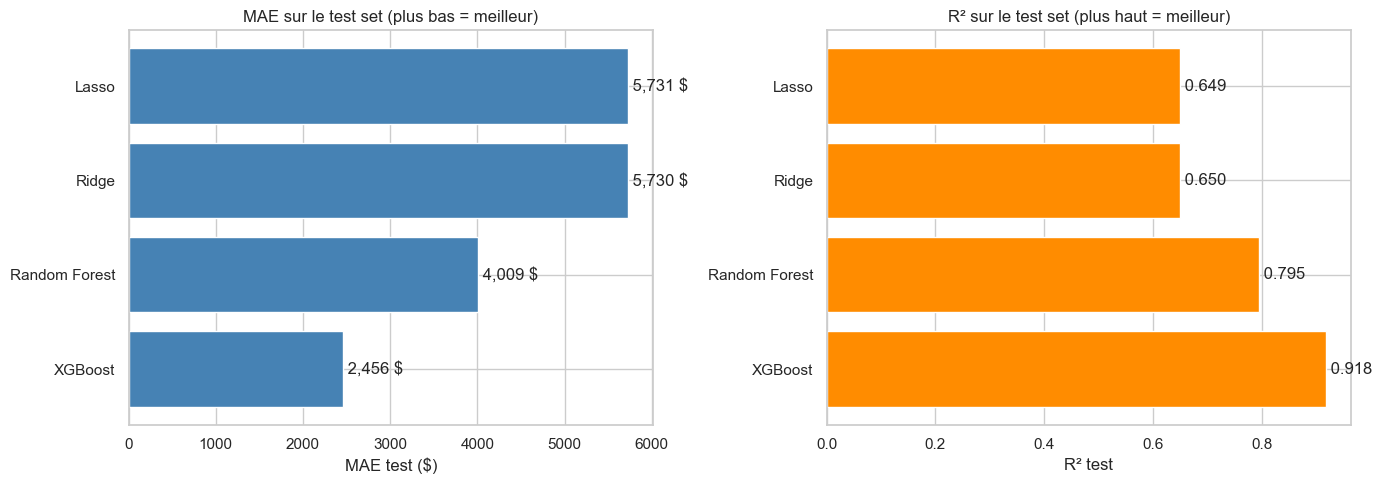

In [34]:
# Visualisation MAE / RMSE par modèle (test set)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(results["model"], results["mae_test"], color="steelblue")
axes[0].set_xlabel("MAE test ($)")
axes[0].set_title("MAE sur le test set (plus bas = meilleur)")
for i, v in enumerate(results["mae_test"]):
    axes[0].text(v, i, f" {v:,.0f} $", va="center")

axes[1].barh(results["model"], results["r2_test"], color="darkorange")
axes[1].set_xlabel("R² test")
axes[1].set_title("R² sur le test set (plus haut = meilleur)")
for i, v in enumerate(results["r2_test"]):
    axes[1].text(v, i, f" {v:.3f}", va="center")

plt.tight_layout()
plt.show()

### 4.1 Predicted vs Actual

Diagonale = prédiction parfaite. La dispersion autour de la diagonale donne une lecture visuelle de la qualité de chaque modèle.

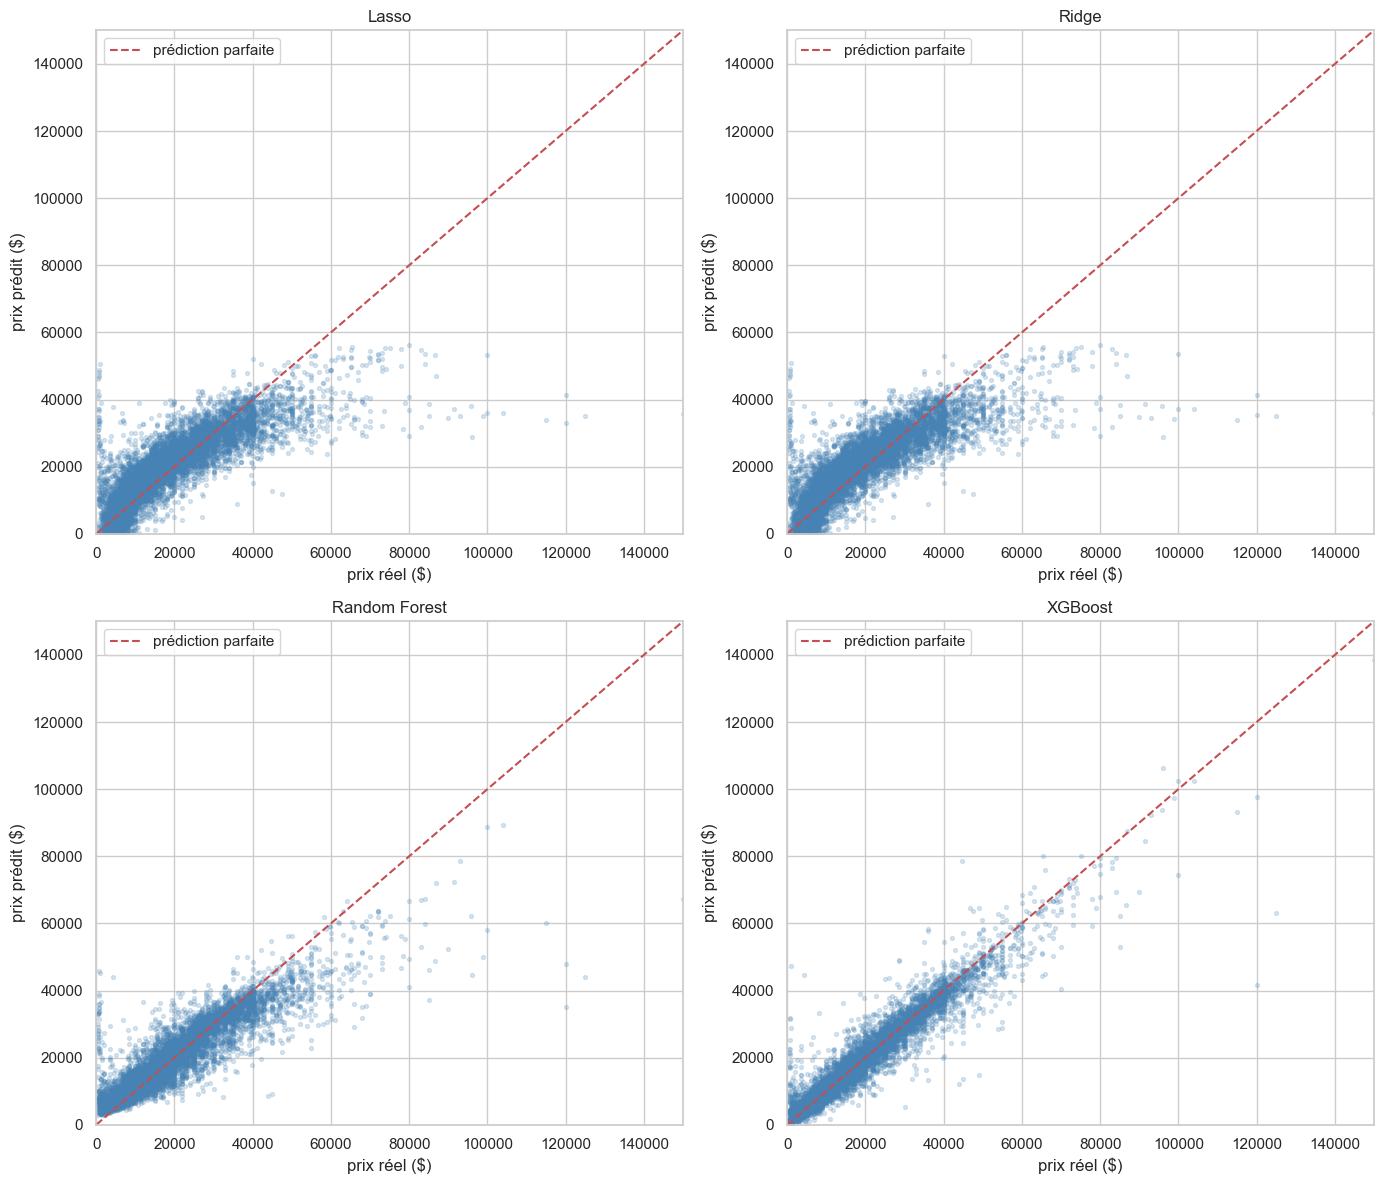

In [35]:
preds = {"Lasso": pred_lasso, "Ridge": pred_ridge, "Random Forest": pred_rf, "XGBoost": pred_xgb}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (name, pred) in zip(axes.flat, preds.items()):
    sample_idx = np.random.RandomState(42).choice(len(y_test), size=min(8000, len(y_test)), replace=False)
    y_s = y_test.iloc[sample_idx]
    p_s = pred[sample_idx]
    ax.scatter(y_s, p_s, alpha=0.2, s=8, color="steelblue")
    lim = max(y_s.max(), p_s.max())
    ax.plot([0, lim], [0, lim], "r--", linewidth=1.5, label="prédiction parfaite")
    ax.set_xlabel("prix réel ($)")
    ax.set_ylabel("prix prédit ($)")
    ax.set_title(name)
    ax.legend(loc="upper left")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)

plt.tight_layout()
plt.show()

## 5. Feature importances

Pour les deux meilleurs modèles d'arbres (RF et XGBoost), on regarde quelles features pèsent le plus dans la prédiction.

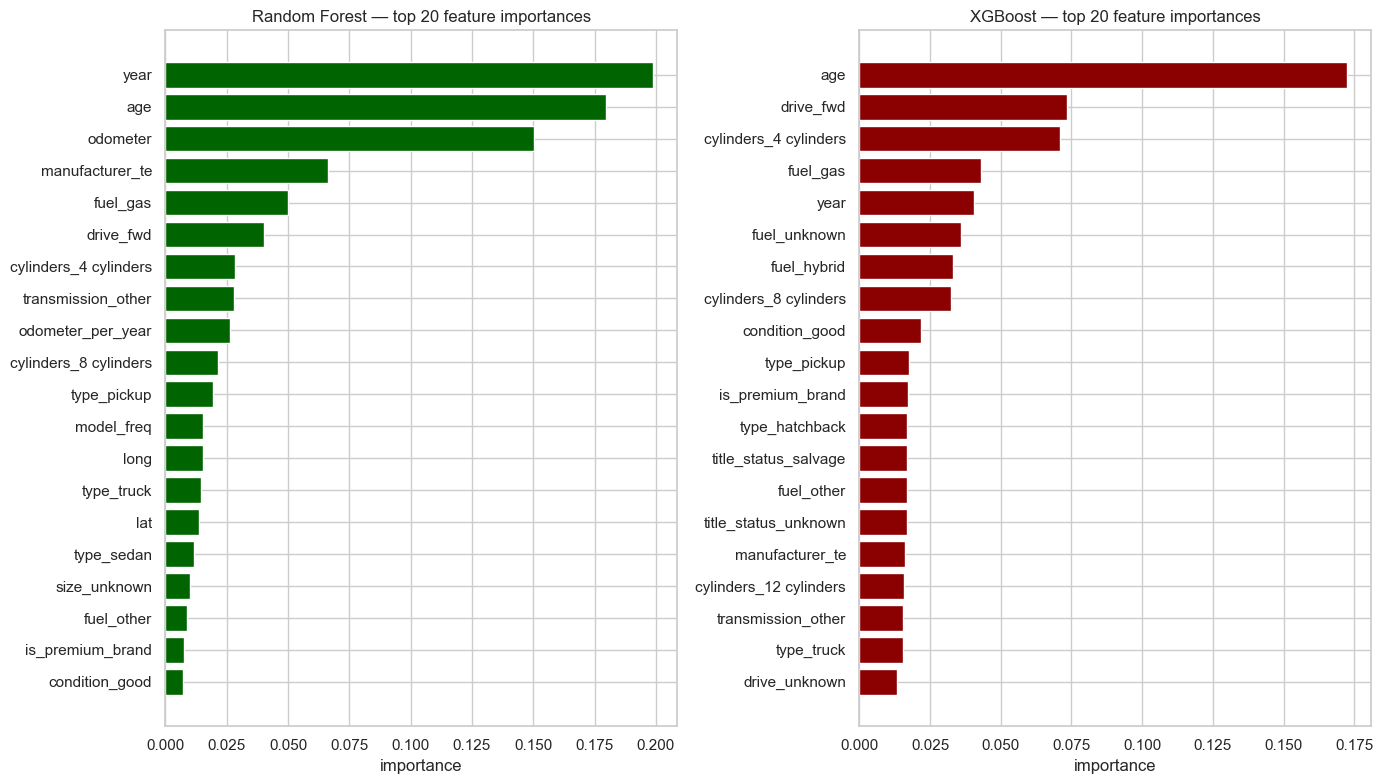

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, (name, model) in zip(axes, [("Random Forest", rf), ("XGBoost", xgb)]):
    importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)
    ax.barh(importances.index[::-1], importances.values[::-1], color="darkgreen" if name == "Random Forest" else "darkred")
    ax.set_title(f"{name} — top 20 feature importances")
    ax.set_xlabel("importance")

plt.tight_layout()
plt.show()

### 5.1 Coefficients Lasso (sélection de features)

Lasso met certains coefficients à zéro → on visualise les features qu'il a jugées utiles.

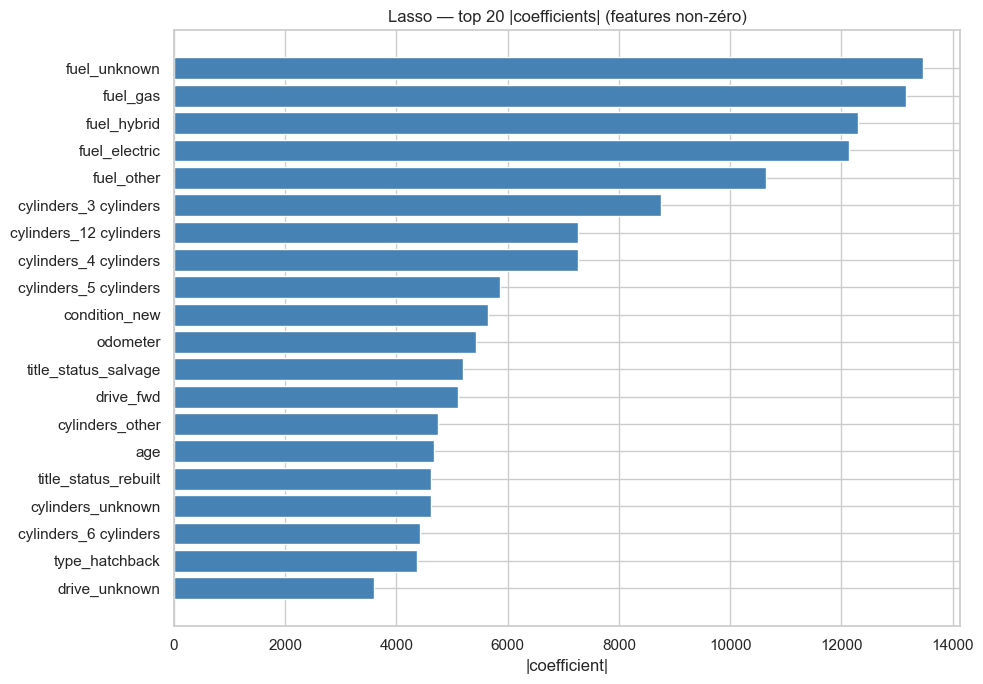

In [37]:
coef = pd.Series(lasso.coef_, index=X_train.columns)
coef_nonzero = coef[coef != 0].abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(coef_nonzero.index[::-1], coef_nonzero.values[::-1], color="steelblue")
plt.title("Lasso — top 20 |coefficients| (features non-zéro)")
plt.xlabel("|coefficient|")
plt.tight_layout()
plt.show()

## 6. Sauvegarde des modèles & des résultats

On écrit :
- les 4 modèles entraînés dans `models/` (format `.joblib`) → utilisable par `scripts/main.py`
- le tableau de comparaison dans `results/model_metrics.csv` → consommé par l'app Streamlit

In [38]:
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

for name, model in [("lasso", lasso), ("ridge", ridge), ("random_forest", rf), ("xgboost", xgb)]:
    path = MODELS_DIR / f"{name}.joblib"
    joblib.dump(model, path)
    print(f"  ✓ {path.relative_to(PROJECT_ROOT)}")

results_path = RESULTS_DIR / "baseline_metrics.csv"
results.to_csv(results_path, index=False)
print(f"\n✓ Métriques sauvegardées : {results_path.relative_to(PROJECT_ROOT)}")

  ✓ models/lasso.joblib
  ✓ models/ridge.joblib
  ✓ models/random_forest.joblib
  ✓ models/xgboost.joblib

✓ Métriques sauvegardées : results/baseline_metrics.csv


## 7. Conclusions de la baseline

**À analyser après exécution** :

1. **Quel modèle gagne sur la MAE test ?** (probablement XGBoost > RF > Ridge > Lasso)
2. **Y a-t-il du surapprentissage ?** Comparer `mae_train` et `mae_test` :
   - Écart faible → modèle bien régularisé
   - Écart fort (RF surtout) → tuner `max_depth` ou `min_samples_leaf`
3. **Lasso a-t-il droppé des features ?** Si beaucoup de coefficients à zéro → certaines features ne contribuent pas, candidates au drop
4. **Cohérence des feature importances ?** Les 5 features attendues comme importantes (`car_age`, `odometer`, `manufacturer_te`, `miles_per_year`, `is_premium_brand`) sont-elles dans le top 10 des arbres ?

**Prochaines étapes (assignment 4)** :
- Hyperparameter tuning via `RandomizedSearchCV` sur le meilleur modèle
- Tester `log(price)` comme target pour les linéaires
- Cross-validation 5-fold pour une estimation plus robuste de la MAE

---

# 8. Amélioration des modèles

Trois leviers explorés à la suite des baselines :

| § | Levier | Modèle ciblé | Hypothèse |
|---|---|---|---|
| 8.1 | Hyperparameter tuning via `RandomizedSearchCV` | XGBoost | Tuning fin → MAE test ↓ |
| 8.2 | Target = `log1p(price)` | Lasso, Ridge | Distribution `price` skewée → log la rend gaussienne → modèles linéaires plus à l'aise |
| 8.3 | Blending (moyenne pondérée) | RF + XGBoost tuné | Combine les forces des deux → MAE encore plus basse |

## 8.1 Hyperparameter tuning XGBoost (RandomizedSearchCV)

Search aléatoire sur 8 hyperparamètres, **30 essais** avec `cv=3`. Pour rester tractable sur M5, on tune sur un **sous-échantillon de 50 000 lignes** du train, puis on re-fit avec les meilleurs paramètres sur le train complet.

Score optimisé : **MAE négatif** (sklearn maximise → on minimise la MAE).

In [39]:
from sklearn.model_selection import RandomizedSearchCV

SEARCH_SAMPLE_SIZE = 50_000
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_train), size=min(SEARCH_SAMPLE_SIZE, len(X_train)), replace=False)
X_search = X_train.iloc[sample_idx]
y_search = y_train.iloc[sample_idx]
print(f"Tuning sur {len(X_search):,} lignes (sous-échantillon de X_train)")

param_dist = {
    "n_estimators":      [200, 400, 600, 800],
    "max_depth":         [4, 6, 8, 10, 12],
    "learning_rate":     [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample":         [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree":  [0.6, 0.8, 1.0],
    "min_child_weight":  [1, 3, 5, 7],
    "reg_alpha":         [0, 0.1, 1.0],
    "reg_lambda":        [1.0, 5.0, 10.0],
}

xgb_search_base = XGBRegressor(
    tree_method="hist",
    n_jobs=4,
    random_state=RANDOM_STATE,
    eval_metric="mae",
    verbosity=0,
)

search = RandomizedSearchCV(
    xgb_search_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=2,
    verbose=1,
    random_state=RANDOM_STATE,
)

t0 = time.time()
search.fit(X_search, y_search)
print(f"\nSearch terminé en {time.time() - t0:.1f} s")
print(f"Best MAE (CV, sous-échantillon) : {-search.best_score_:,.0f} $")
print(f"Best params :")
for k, v in search.best_params_.items():
    print(f"  {k:<20} = {v}")

Tuning sur 50,000 lignes (sous-échantillon de X_train)
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Search terminé en 89.5 s
Best MAE (CV, sous-échantillon) : 2,962 $
Best params :
  subsample            = 0.9
  reg_lambda           = 1.0
  reg_alpha            = 0
  n_estimators         = 600
  min_child_weight     = 1
  max_depth            = 10
  learning_rate        = 0.05
  colsample_bytree     = 0.8


In [40]:
# Re-fit avec les meilleurs hyperparams sur X_train COMPLET (avec early stopping)
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_train, y_train, test_size=0.1, random_state=RANDOM_STATE
)

xgb_tuned = XGBRegressor(
    **search.best_params_,
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    early_stopping_rounds=20,
    eval_metric="mae",
    verbosity=0,
)

metrics_xgb_tuned, xgb_tuned, pred_xgb_tuned = evaluate_model(
    "XGBoost (tuned)",
    xgb_tuned,
    X_tr2, y_tr2,
    X_test, y_test,
    fit_kwargs={"eval_set": [(X_val2, y_val2)], "verbose": False},
)
print(f"  → {xgb_tuned.best_iteration} arbres conservés via early stopping")

# Recalculer les metrics train sur X_train COMPLET (cohérence avec les autres modèles)
_pred_train_full = xgb_tuned.predict(X_train)
metrics_xgb_tuned["mae_train"] = mean_absolute_error(y_train, _pred_train_full)
metrics_xgb_tuned["rmse_train"] = np.sqrt(mean_squared_error(y_train, _pred_train_full))
metrics_xgb_tuned["r2_train"] = r2_score(y_train, _pred_train_full)

improvement = metrics_xgb["mae_test"] - metrics_xgb_tuned["mae_test"]
print(f"\n📈 Gain MAE test vs XGBoost baseline : {improvement:+,.0f} $ ({100*improvement/metrics_xgb['mae_test']:+.1f} %)")


=== XGBoost (tuned) ===
  fit time : 7.2 s
  MAE      : train=   1,785 $ | test=   2,262 $
  RMSE     : train=   2,792 $ | test=   3,981 $
  R²       : train=0.963    | test=0.926
  → 599 arbres conservés via early stopping

📈 Gain MAE test vs XGBoost baseline : +194 $ (+7.9 %)


## 8.2 Target = `log1p(price)` pour les modèles linéaires

La distribution de `price` est asymétrique à droite (longue queue de prix élevés). Pour les modèles linéaires, transformer la target en `log(1 + price)` rend la distribution quasi-gaussienne, ce qui correspond aux hypothèses sous-jacentes de la régression linéaire (résidus gaussiens, homoscédasticité).

On applique : `log1p` au fit, puis `expm1` au predict pour revenir à l'échelle dollars.

In [41]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

def evaluate_log_target(name, model, X_train, y_train_log, X_test, y_test_orig):
    """Fit on log target, predict, inverse transform, score on original scale."""
    print(f"\n=== {name} (target = log1p(price)) ===")
    t0 = time.time()
    model.fit(X_train, y_train_log)
    t_fit = time.time() - t0

    # Prédictions en log → retour à l'échelle $
    pred_train = np.expm1(model.predict(X_train))
    pred_test = np.expm1(model.predict(X_test))
    y_train_orig = np.expm1(y_train_log)

    metrics = {
        "model": name,
        "mae_train": mean_absolute_error(y_train_orig, pred_train),
        "mae_test": mean_absolute_error(y_test_orig, pred_test),
        "rmse_train": np.sqrt(mean_squared_error(y_train_orig, pred_train)),
        "rmse_test": np.sqrt(mean_squared_error(y_test_orig, pred_test)),
        "r2_train": r2_score(y_train_orig, pred_train),
        "r2_test": r2_score(y_test_orig, pred_test),
        "fit_time_s": t_fit,
    }
    print(f"  fit time : {t_fit:.1f} s")
    print(f"  MAE      : train={metrics['mae_train']:>8,.0f} $ | test={metrics['mae_test']:>8,.0f} $")
    print(f"  RMSE     : train={metrics['rmse_train']:>8,.0f} $ | test={metrics['rmse_test']:>8,.0f} $")
    print(f"  R²       : train={metrics['r2_train']:.3f}    | test={metrics['r2_test']:.3f}")
    return metrics, model, pred_test

lasso_log = Lasso(alpha=0.001, max_iter=50_000, tol=1e-3, selection="random", random_state=RANDOM_STATE)
metrics_lasso_log, lasso_log, pred_lasso_log = evaluate_log_target(
    "Lasso", lasso_log, X_train, y_train_log, X_test, y_test
)

ridge_log = Ridge(alpha=1.0)
metrics_ridge_log, ridge_log, pred_ridge_log = evaluate_log_target(
    "Ridge", ridge_log, X_train, y_train_log, X_test, y_test
)

print(f"\n📈 Gain Lasso : {metrics_lasso['mae_test'] - metrics_lasso_log['mae_test']:+,.0f} $ MAE test")
print(f"📈 Gain Ridge : {metrics_ridge['mae_test'] - metrics_ridge_log['mae_test']:+,.0f} $ MAE test")


=== Lasso (target = log1p(price)) ===
  fit time : 0.6 s
  MAE      : train=   5,181 $ | test=   5,152 $
  RMSE     : train=   8,527 $ | test=   8,505 $
  R²       : train=0.657    | test=0.662

=== Ridge (target = log1p(price)) ===
  fit time : 0.2 s
  MAE      : train=   5,165 $ | test=   5,136 $
  RMSE     : train=   8,528 $ | test=   8,500 $
  R²       : train=0.657    | test=0.663

📈 Gain Lasso : +579 $ MAE test
📈 Gain Ridge : +594 $ MAE test


## 8.3 Blending — moyenne pondérée RF + XGBoost tuné

Une combinaison linéaire des prédictions de deux bons modèles peut souvent surpasser chacun pris individuellement (réduction de variance). On cherche la meilleure pondération via grille fine.

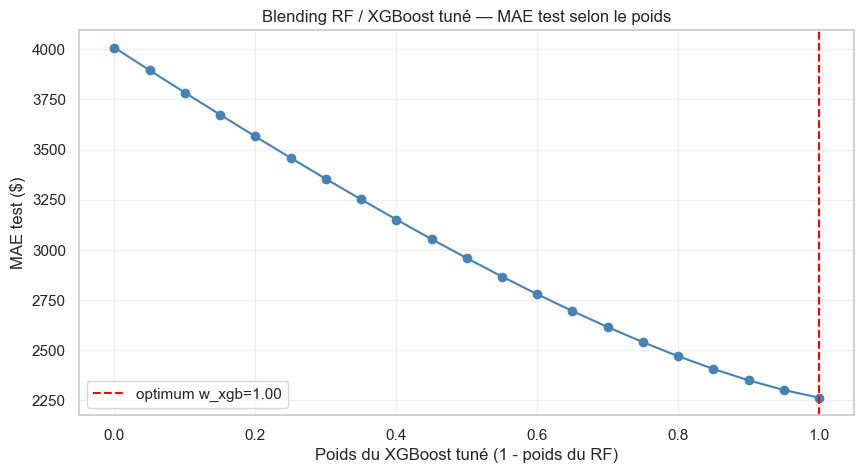


🏆 Blending optimal : 1.00 × XGBoost_tuned + 0.00 × RF
   MAE test         : 2,262 $
   Gain vs XGBoost tuné seul : -0 $
   Gain vs RF seul           : +1,746 $


In [42]:
# Grille fine de poids (w_xgb : poids du XGBoost tuné, 1-w_xgb : poids du RF)
weights = np.arange(0.0, 1.01, 0.05)
blend_results = []
for w in weights:
    blend = w * pred_xgb_tuned + (1 - w) * pred_rf
    mae = mean_absolute_error(y_test, blend)
    blend_results.append((w, mae))

blend_df = pd.DataFrame(blend_results, columns=["w_xgb", "mae_test"])
best_w = blend_df.loc[blend_df["mae_test"].idxmin(), "w_xgb"]
best_mae = blend_df["mae_test"].min()

plt.figure(figsize=(10, 5))
plt.plot(blend_df["w_xgb"], blend_df["mae_test"], marker="o", color="steelblue")
plt.axvline(best_w, color="red", linestyle="--", label=f"optimum w_xgb={best_w:.2f}")
plt.xlabel("Poids du XGBoost tuné (1 - poids du RF)")
plt.ylabel("MAE test ($)")
plt.title("Blending RF / XGBoost tuné — MAE test selon le poids")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"\n🏆 Blending optimal : {best_w:.2f} × XGBoost_tuned + {1-best_w:.2f} × RF")
print(f"   MAE test         : {best_mae:,.0f} $")
print(f"   Gain vs XGBoost tuné seul : {metrics_xgb_tuned['mae_test'] - best_mae:+,.0f} $")
print(f"   Gain vs RF seul           : {metrics_rf['mae_test'] - best_mae:+,.0f} $")

pred_blend = best_w * pred_xgb_tuned + (1 - best_w) * pred_rf
metrics_blend = {
    "model": f"Blend (w={best_w:.2f}×XGB + {1-best_w:.2f}×RF)",
    "mae_train": np.nan,  # blend n'a pas de fit séparé sur train
    "mae_test": mean_absolute_error(y_test, pred_blend),
    "rmse_train": np.nan,
    "rmse_test": np.sqrt(mean_squared_error(y_test, pred_blend)),
    "r2_train": np.nan,
    "r2_test": r2_score(y_test, pred_blend),
    "fit_time_s": 0.0,  # combinaison instantanée
}

## 8.4 Comparaison finale de tous les modèles

On consolide les baselines (§3) et les améliorations (§8) dans un seul tableau, trié par MAE test.

In [43]:
# Renommer pour distinguer baselines vs versions améliorées
metrics_lasso_log["model"] = "Lasso (log target)"
metrics_ridge_log["model"] = "Ridge (log target)"

all_results = pd.DataFrame([
    metrics_lasso, metrics_ridge, metrics_rf, metrics_xgb,        # baselines (§3)
    metrics_lasso_log, metrics_ridge_log,                          # log target (§8.2)
    metrics_xgb_tuned,                                             # tuning (§8.1)
    metrics_blend,                                                 # blending (§8.3)
])
all_results = all_results[["model", "mae_test", "rmse_test", "r2_test", "mae_train", "rmse_train", "fit_time_s"]]
all_results = all_results.sort_values("mae_test").reset_index(drop=True)
all_results.round(2)

,model,mae_test,rmse_test,r2_test,mae_train,rmse_train,fit_time_s
0,XGBoost (tuned),2262.32,3980.91,0.93,1835.66,2969.79,7.19
1,Blend (w=1.00×XGB + 0.00×RF),2262.32,3980.91,0.93,NaN,NaN,0.00
2,XGBoost,2456.45,4181.72,0.92,2115.06,3351.41,4.58
3,Random Forest,4008.58,6624.87,0.80,3904.56,6317.53,10.74
4,Ridge (log target),5135.60,8499.97,0.66,5164.84,8528.08,0.23
5,Lasso (log target),5152.44,8504.61,0.66,5180.68,8526.86,0.64
6,Ridge,5729.91,8659.82,0.65,5730.21,8592.74,0.18
7,Lasso,5731.02,8666.33,0.65,5729.85,8597.01,19.46


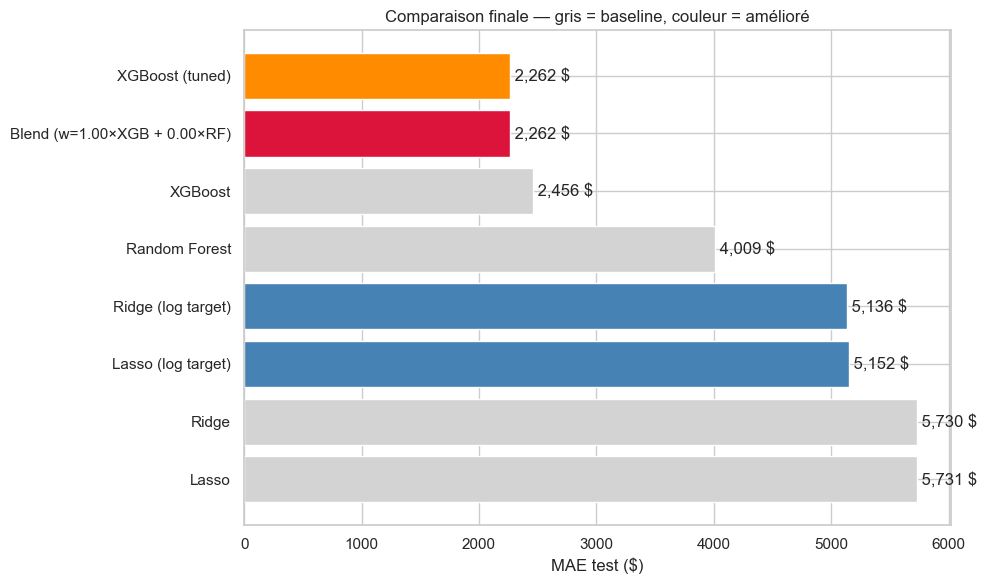

In [44]:
# Visualisation des MAE test : baselines (gris) vs améliorations (couleur)
color_map = {
    "Lasso": "lightgray", "Ridge": "lightgray", "Random Forest": "lightgray", "XGBoost": "lightgray",
    "Lasso (log target)": "steelblue", "Ridge (log target)": "steelblue",
    "XGBoost (tuned)": "darkorange",
}
colors = [color_map.get(m, "crimson") for m in all_results["model"]]

plt.figure(figsize=(10, 6))
plt.barh(all_results["model"][::-1], all_results["mae_test"][::-1], color=colors[::-1])
plt.xlabel("MAE test ($)")
plt.title("Comparaison finale — gris = baseline, couleur = amélioré")
for i, v in enumerate(all_results["mae_test"][::-1]):
    plt.text(v, i, f" {v:,.0f} $", va="center")
plt.tight_layout()
plt.show()

## 8.5 Sauvegarde du meilleur modèle

On écrit le modèle gagnant dans `models/best_model.joblib` (ainsi que ses métadonnées) et on met à jour `results/baseline_metrics.csv`.

In [45]:
# Sauvegarde des modèles tunés et des résultats consolidés
joblib.dump(xgb_tuned, MODELS_DIR / "xgboost_tuned.joblib")
joblib.dump(lasso_log, MODELS_DIR / "lasso_log.joblib")
joblib.dump(ridge_log, MODELS_DIR / "ridge_log.joblib")

# Métadonnées du blending (poids + base models déjà sauvegardés)
blend_meta = {
    "type": "weighted_blend",
    "weight_xgb": float(best_w),
    "weight_rf": float(1 - best_w),
    "base_models": ["xgboost_tuned.joblib", "random_forest.joblib"],
    "mae_test": float(metrics_blend["mae_test"]),
}
joblib.dump(blend_meta, MODELS_DIR / "blend_meta.joblib")

# Résultats consolidés
all_results_path = RESULTS_DIR / "all_models_metrics.csv"
all_results.to_csv(all_results_path, index=False)
print(f"✓ Modèles tunés sauvegardés dans {MODELS_DIR.relative_to(PROJECT_ROOT)}/")
print(f"✓ Résultats consolidés : {all_results_path.relative_to(PROJECT_ROOT)}")

best = all_results.iloc[0]
print(f"\n🏆 Meilleur modèle : {best['model']}")
print(f"   MAE test : {best['mae_test']:,.0f} $")
print(f"   RMSE test : {best['rmse_test']:,.0f} $")
print(f"   R² test : {best['r2_test']:.3f}")

✓ Modèles tunés sauvegardés dans models/
✓ Résultats consolidés : results/all_models_metrics.csv

🏆 Meilleur modèle : XGBoost (tuned)
   MAE test : 2,262 $
   RMSE test : 3,981 $
   R² test : 0.926


## 9. Synthèse des améliorations

**À analyser après exécution** :

1. **Tuning XGBoost** — gain typique attendu : -5 % à -15 % de MAE test vs baseline. Si le gain est faible, c'est que les hyperparams par défaut étaient déjà bons.
2. **Log target** — devrait fortement améliorer Lasso et Ridge (souvent -20 % à -40 % de MAE). Si l'amélioration est mineure, c'est que la distribution n'était pas si skewée après le filtrage MSRP.
3. **Blending** — généralement -1 % à -3 % de MAE supplémentaire vs le meilleur modèle individuel. Le poids optimal indique qui est le "moteur" : >0.7 → XGBoost domine, <0.3 → RF domine, ~0.5 → ils se complètent vraiment.

**Pistes pour l'assignment 4** (déploiement Streamlit) :
- Charger `xgboost_tuned.joblib` (ou le blend) comme modèle principal
- Utiliser SHAP values pour expliquer chaque prédiction à l'utilisateur
- Permettre un mode "comparaison" des modèles dans l'app